# MASTER THESIS - model V4 summer

This notebook demonstrates the usage of the `DarkGreyBox` models via fitting them with `DarkGreyFit`

Model V3 --> this model is using the TiTmCn3R2C grey-box model on a summer period (1st of September to 15th of September) where there is no heating at all

## Importation

In [1]:
import sys
import importlib
from pathlib import Path

# go from ...\docs\tutorials up two levels to the repo root (...\darkgreybox)
repo_root = Path.cwd().parents[1]
sys.path.insert(0, str(repo_root))
importlib.invalidate_caches()


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, KFold
from statsmodels.graphics.tsaplots import plot_pacf

from darkgreybox.models import TiTmTfCn3R3C_summer_V13
from darkgreybox.fit import darkgreyfit
from docs.tutorials.util.plot import plot
from docs.tutorials.util.error import rmse

2026-02-27 00:14:34,892 darkgreybox  INFO     Logging enabled...


Our temporal resolution is 5 minutes

In [2]:
# the duration of a record (in h - 5 minutes)
rec_duration = 5/60

## Data Loading and Preprocessing

The data is loaded from the CSV file 'data_summer' and processed to extract relevant variables for the thermal model.

In [3]:
input_df = pd.read_csv('./data/data_summer.csv', index_col=0, parse_dates=True)

input_df['Ti_meas'] = input_df['R01_06_TRU01']
input_df['qv'] = input_df['R01_06_FCI01']
input_df['c'] = input_df['R01_06_CO201']  # Use processed CO2 column
input_df['Ta'] = input_df['HTR9_VES01_TUD01']
input_df['Ik'] = input_df['HTR9_VES01_SI01']
input_df['Tsup'] = input_df['HTRK_VEN01_SpTI01_C']


# Set initial conditions
input_df['Ti0'] = input_df['Ti_meas'].iloc[0]
input_df['Tm0'] = input_df['Ti_meas'].iloc[0]
input_df['Tf0']   = input_df['Ti_meas'].iloc[0]   # ← NEW: start at air temp
input_df['c0'] = input_df['c'].iloc[0]
input_df['N0'] = 0 #We suppose no one in the room at the beginning
input_df['P0_Ti'] = 1.0  # Initial state covariance for Ti
input_df['P0_Tm'] = 1.0  # Initial state covariance for Tm
input_df['P0_Tf'] = 1.0                           # ← NEW
input_df['P0_N'] = 4.0  # Initial state covariance for N


input_X = input_df[['qv', 'c', 'Ta', 'Ik', 'Ti_meas', 'Tsup',
                     'Ti0', 'Tm0', 'Tf0', 'c0', 'N0',
                     'P0_Ti', 'P0_Tm', 'P0_Tf', 'P0_N']]   # ← Tf0, P0_Tf added
input_y = input_df['Ti_meas']

print(f'Input X shape: {input_X.shape}, input y shape: {input_y.shape}')


Input X shape: (4296, 15), input y shape: (4296,)


## Data Splitting

Initial conditions are set for the state variables at t=0, using the first measurements from the dataset. The data is then split into training (80%) and test (20%) sets for model validation.
`shuffle=False` to preserve the temporal order of the time series data. This is important for thermal modeling where historical context matters.

In [4]:
X_train, X_test, y_train, y_test = train_test_split(input_X, input_y, test_size=0.2, shuffle=False)

print(f'Train: X shape: {X_train.shape}, y shape: {y_train.shape}')
print(f'Test: X shape: {X_test.shape}, y shape: {y_test.shape}')

Train: X shape: (3436, 15), y shape: (3436,)
Test: X shape: (860, 15), y shape: (860,)


## Model Training Parameters and Physical Constants

The parameter ranges are carefully chosen to reflect realistic physical bounds and to ensure the optimizer does not hit artificial limits during fitting. Capacitances and resistances are estimated from building material properties and geometry, while internal gains and constants are set according to typical values found in literature or building standards. This approach balances physical realism with flexibility for model calibration.


In [ ]:
S_room = 11                             #Surface of the room, found on Revit (m²)
A_windows = 5.48                        #Window area found on Revit (m²)
H_room = 2.7                            #Height of the room (m)
V_room = S_room * H_room                #Volume of the room (m³)



# Define training parameters
train_params_TiTmCn2R2C_summer = {
    # ── Initial states ────────────────────────────────────────────────────
    'Ti0': {'value': input_df.iloc[0]['Ti0'], 'vary': False},
    'Tm0': {'value': input_df.iloc[0]['Tm0'], 'vary': False},
    'Tf0': {'value': input_df.iloc[0]['Tf0'], 'vary': False},   # ← NEW
    'c0':  {'value': input_df.iloc[0]['c0'],  'vary': False},
    'N0':  {'value': input_df.iloc[0]['N0'],  'vary': False},

    # ── Thermal RC parameters ─────────────────────────────────────────────
    'Ci':   {'value': 5000,   'vary': True, 'min': 1000,   'max': 50000},
    'Cm':   {'value': 100000, 'vary': True, 'min': 1000,   'max': 1000000},
    'Rim':  {'value': 0.005,  'vary': True, 'min': 0.001,  'max': 0.01},
    'Rout': {'value': 0.15,   'vary': True, 'min': 0.01,   'max': 2.0},
    'Rf':   {'value': 0.05,   'vary': True, 'min': 0.001,  'max': 1.0},    # ← NEW
    'Cf':   {'value': 5000,   'vary': True, 'min': 500,    'max': 100000}, # ← NEW

    # ── Gains ─────────────────────────────────────────────────────────────
    'q_equip_var':   {'value': 80,  'vary': False},
    'q_equip_const': {'value': 10,  'vary': False},
    'g':             {'value': 0.55,'vary': False},

    # ── Room geometry ─────────────────────────────────────────────────────
    'V':   {'value': S_room * H_room, 'vary': False},
    'S':   {'value': S_room,          'vary': False},
    'A':   {'value': A_windows,       'vary': False},

    # ── Air properties ────────────────────────────────────────────────────
    'rho_air': {'value': 1.2,  'vary': False},
    'cp_air':  {'value': 1000, 'vary': False},

    # ── CO2 / occupancy ───────────────────────────────────────────────────
    'c_out':    {'value': 400,  'vary': False},
    'G_base':   {'value': 0.016,'vary': False},
    'Met':      {'value': 1.2,  'vary': False},
    'alpha_lat':{'value': 40.0, 'vary': True, 'min': 20.0, 'max': 60.0},

    # ── KF noise ──────────────────────────────────────────────────────────
    'sigma_Ti':      {'value': 0.02,  'vary': True,  'min': 1e-4, 'max': 1.0},
    'sigma_Tm':      {'value': 0.01,  'vary': True,  'min': 1e-4, 'max': 1.0},
    'sigma_Tf':      {'value': 0.02,  'vary': True,  'min': 1e-4, 'max': 1.0},  # ← NEW
    'sigma_N':       {'value': 0.5,   'vary': True,  'min': 0.01, 'max': 5.0},
    'sigma_Ti_meas': {'value': 0.3, 'vary': False},
    'sigma_c':       {'value': 50.0,  'vary': False},   # ppm — sensor spec

    # ── KF initial covariances ────────────────────────────────────────────
    'P0_Ti': {'value': 1.0, 'vary': False},
    'P0_Tm': {'value': 1.0, 'vary': False},
    'P0_Tf': {'value': 1.0, 'vary': False},   # ← NEW
    'P0_N':  {'value': 4.0, 'vary': False},
}

# Verify stability
print(f"dt = {rec_duration:.4f} hours ({rec_duration * 60:.2f} minutes)")

dt = 0.0833 hours (5.00 minutes)


### 1: Initial conditions
Set up our initial conditions parameters map for testing

### 2: Error metric
To evaluate the performance of our models we will need to define an error metric. Again, there is a wide range of options available from `sklearn`

### 3: Fit method
Under the hood, `DarkGreyBox` uses `lmfit.minimize` to fit the thermal model parameters to the training data by passing it a custom objective function defined by the model class. The fit method used by `lmfit.minimize` can be customised as well. The standard Nelder-Mead and Levenberg-Marquardt methods work well in general. Here we use the Nelder-Mead method.

### 4: Choice of the model

In [6]:
from lmfit import Parameters, minimize as lmfit_minimize

method = 'nelder'   # ← ADD THIS

def build_lmfit_params(params_dict):
    p = Parameters()
    for name, spec in params_dict.items():
        if isinstance(spec, dict):
            p.add(name, **{k: v for k, v in spec.items()
                           if k in ('value', 'vary', 'min', 'max', 'expr')})
        else:
            p.add(name, value=float(spec))
    return p

lmfit_params = build_lmfit_params(train_params_TiTmCn2R2C_summer)

# ← class name updated to V13
model = TiTmTfCn3R3C_summer_V13(train_params_TiTmCn2R2C_summer, rec_duration)

def loglik_objective(params):
    result = model.model(params, X_train)
    z = result.var['z_Ti'][1:]
    S = result.var['S_Ti'][1:]
    return 0.5 * np.sum(z**2 / S + np.log(S))

print("Training model...")
fit_result    = lmfit_minimize(loglik_objective, lmfit_params, method=method)
model.result  = fit_result
fitted_params = fit_result.params

train_results = model.model(fitted_params, X_train)

test_params = fitted_params.copy()
test_params['Ti0'].set(value=float(y_test.iloc[0]))
test_params['Tm0'].set(value=float(train_results.var['Tm'][-1]))
test_params['Tf0'].set(value=float(train_results.var['Tf'][-1]))  # ← NEW
test_params['c0'].set(value=float(train_results.var['c'][-1]))
test_params['N0'].set(value=float(train_results.var['N'][-1]))

test_results = model.model(test_params, X_test)
print("Fitting complete!")

from docs.tutorials.util.error import rmse
print(f"Train RMSE: {rmse(train_results.var['Ti'], y_train.values):.4f} °C")
print(f"Test  RMSE: {rmse(test_results.var['Ti'],  y_test.values):.4f} °C")


Training model...
Fitting complete!
Train RMSE: 0.0000 °C
Test  RMSE: 0.0000 °C


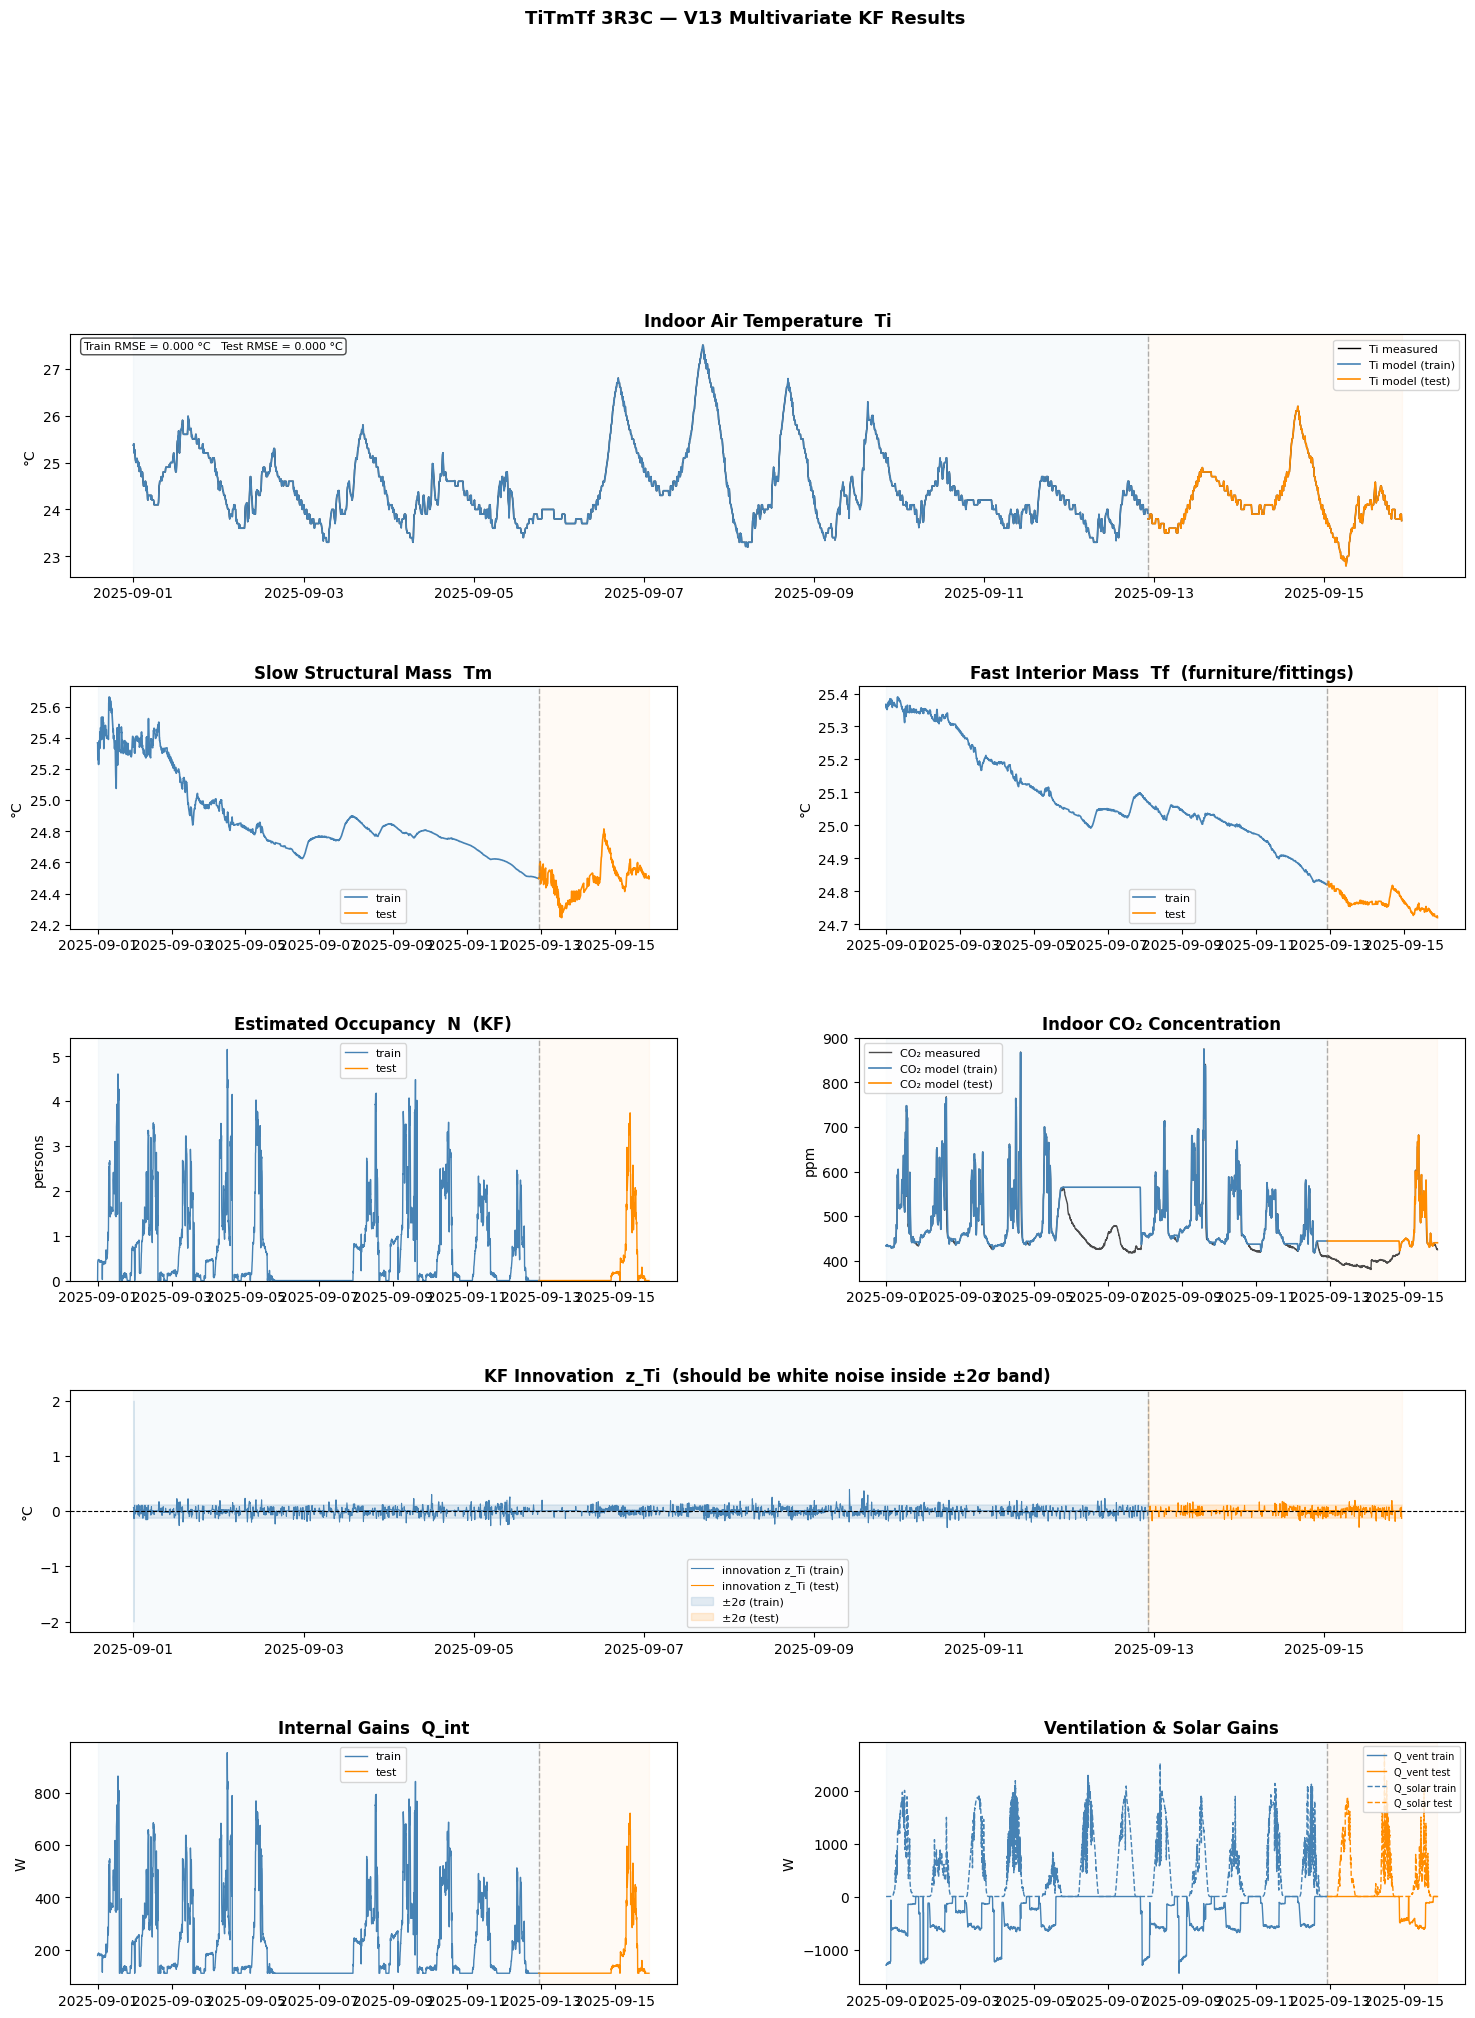

In [7]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

# ── Reconstruct time index ────────────────────────────────────────────────────
train_index = X_train.index
test_index  = X_test.index

# ── Unpack results ────────────────────────────────────────────────────────────
Ti_train   = train_results.var['Ti']
Tm_train   = train_results.var['Tm']
Tf_train   = train_results.var['Tf']     # ← NEW
N_train    = train_results.var['N']
c_train    = train_results.var['c']
z_train    = train_results.var['z_Ti']
S_train    = train_results.var['S_Ti']
Qint_train = train_results.var['Q_int']
Qven_train = train_results.var['Q_vent']
Qsol_train = train_results.var['Q_solar']

Ti_test    = test_results.var['Ti']
Tm_test    = test_results.var['Tm']
Tf_test    = test_results.var['Tf']      # ← NEW
N_test     = test_results.var['N']
c_test     = test_results.var['c']
z_test     = test_results.var['z_Ti']
S_test     = test_results.var['S_Ti']
Qint_test  = test_results.var['Q_int']
Qven_test  = test_results.var['Q_vent']
Qsol_test  = test_results.var['Q_solar']

c_meas_train = np.asarray(X_train['c'], dtype=float)
c_meas_test  = np.asarray(X_test['c'],  dtype=float)

sigma_2_train = 2.0 * np.sqrt(np.abs(S_train))
sigma_2_test  = 2.0 * np.sqrt(np.abs(S_test))

# ── Figure layout (6 rows to fit Tf panel) ───────────────────────────────────
fig = plt.figure(figsize=(18, 26))
gs  = gridspec.GridSpec(6, 2, figure=fig, hspace=0.45, wspace=0.3)

ax_ti   = fig.add_subplot(gs[0, :])   # full width
ax_tm   = fig.add_subplot(gs[1, 0])
ax_tf   = fig.add_subplot(gs[1, 1])   # ← NEW: fast mass Tf
ax_n    = fig.add_subplot(gs[2, 0])
ax_co2  = fig.add_subplot(gs[2, 1])
ax_inn  = fig.add_subplot(gs[3, :])   # full width
ax_qint = fig.add_subplot(gs[4, 0])
ax_qven = fig.add_subplot(gs[4, 1])

# ── Helper ────────────────────────────────────────────────────────────────────
def shade_split(ax):
    ax.axvline(test_index[0], color='grey', lw=1, ls='--', alpha=0.6)
    ax.axvspan(train_index[0], test_index[0],  alpha=0.04, color='steelblue')
    ax.axvspan(test_index[0],  test_index[-1], alpha=0.04, color='darkorange')

# ── 1. Ti ─────────────────────────────────────────────────────────────────────
ax_ti.plot(train_index, y_train,  color='black',      lw=1.0, label='Ti measured')
ax_ti.plot(train_index, Ti_train, color='steelblue',  lw=1.2, label='Ti model (train)')
ax_ti.plot(test_index,  y_test,   color='black',      lw=1.0)
ax_ti.plot(test_index,  Ti_test,  color='darkorange', lw=1.2, label='Ti model (test)')
shade_split(ax_ti)
ax_ti.set_title('Indoor Air Temperature  Ti', fontweight='bold')
ax_ti.set_ylabel('°C')
ax_ti.legend(fontsize=8)
ax_ti.text(0.01, 0.97,
    f'Train RMSE = {rmse(Ti_train, y_train.values):.3f} °C   '
    f'Test RMSE = {rmse(Ti_test, y_test.values):.3f} °C',
    transform=ax_ti.transAxes, va='top', fontsize=8,
    bbox=dict(boxstyle='round', fc='white', alpha=0.7))

# ── 2. Tm (slow structural mass) ──────────────────────────────────────────────
ax_tm.plot(train_index, Tm_train, color='steelblue',  lw=1.2, label='train')
ax_tm.plot(test_index,  Tm_test,  color='darkorange', lw=1.2, label='test')
shade_split(ax_tm)
ax_tm.set_title('Slow Structural Mass  Tm', fontweight='bold')
ax_tm.set_ylabel('°C')
ax_tm.legend(fontsize=8)

# ── 3. Tf (fast interior mass) — NEW ──────────────────────────────────────────
ax_tf.plot(train_index, Tf_train, color='steelblue',  lw=1.2, label='train')
ax_tf.plot(test_index,  Tf_test,  color='darkorange', lw=1.2, label='test')
shade_split(ax_tf)
ax_tf.set_title('Fast Interior Mass  Tf  (furniture/fittings)', fontweight='bold')
ax_tf.set_ylabel('°C')
ax_tf.legend(fontsize=8)

# ── 4. Occupancy N ────────────────────────────────────────────────────────────
ax_n.plot(train_index, N_train, color='steelblue',  lw=1.0, label='train')
ax_n.plot(test_index,  N_test,  color='darkorange', lw=1.0, label='test')
ax_n.set_ylim(bottom=0)
shade_split(ax_n)
ax_n.set_title('Estimated Occupancy  N  (KF)', fontweight='bold')
ax_n.set_ylabel('persons')
ax_n.legend(fontsize=8)

# ── 5. CO2 ────────────────────────────────────────────────────────────────────
ax_co2.plot(train_index, c_meas_train, color='black',      lw=1.0, alpha=0.7, label='CO₂ measured')
ax_co2.plot(train_index, c_train,      color='steelblue',  lw=1.2, label='CO₂ model (train)')
ax_co2.plot(test_index,  c_meas_test,  color='black',      lw=1.0, alpha=0.7)
ax_co2.plot(test_index,  c_test,       color='darkorange', lw=1.2, label='CO₂ model (test)')
shade_split(ax_co2)
ax_co2.set_title('Indoor CO₂ Concentration', fontweight='bold')
ax_co2.set_ylabel('ppm')
ax_co2.legend(fontsize=8)

# ── 6. KF innovations ─────────────────────────────────────────────────────────
ax_inn.plot(train_index, z_train, color='steelblue',  lw=0.8, label='innovation z_Ti (train)')
ax_inn.plot(test_index,  z_test,  color='darkorange', lw=0.8, label='innovation z_Ti (test)')
ax_inn.fill_between(train_index,  sigma_2_train, -sigma_2_train,
                    color='steelblue',  alpha=0.15, label='±2σ (train)')
ax_inn.fill_between(test_index,   sigma_2_test,  -sigma_2_test,
                    color='darkorange', alpha=0.15, label='±2σ (test)')
ax_inn.axhline(0, color='black', lw=0.8, ls='--')
shade_split(ax_inn)
ax_inn.set_title('KF Innovation  z_Ti  (should be white noise inside ±2σ band)', fontweight='bold')
ax_inn.set_ylabel('°C')
ax_inn.legend(fontsize=8)

# ── 7. Internal heat gains ────────────────────────────────────────────────────
ax_qint.plot(train_index, Qint_train, color='steelblue',  lw=1.0, label='train')
ax_qint.plot(test_index,  Qint_test,  color='darkorange', lw=1.0, label='test')
shade_split(ax_qint)
ax_qint.set_title('Internal Gains  Q_int', fontweight='bold')
ax_qint.set_ylabel('W')
ax_qint.legend(fontsize=8)

# ── 8. Ventilation + solar ────────────────────────────────────────────────────
ax_qven.plot(train_index, Qven_train, color='steelblue',  lw=1.0, label='Q_vent train')
ax_qven.plot(test_index,  Qven_test,  color='darkorange', lw=1.0, label='Q_vent test')
ax_qven.plot(train_index, Qsol_train, color='steelblue',  lw=1.0, ls='--', label='Q_solar train')
ax_qven.plot(test_index,  Qsol_test,  color='darkorange', lw=1.0, ls='--', label='Q_solar test')
shade_split(ax_qven)
ax_qven.set_title('Ventilation & Solar Gains', fontweight='bold')
ax_qven.set_ylabel('W')
ax_qven.legend(fontsize=7)

fig.suptitle('TiTmTf 3R3C — V13 Multivariate KF Results', fontsize=13, fontweight='bold', y=1.005)
plt.savefig('V13_results.png', dpi=150, bbox_inches='tight')
plt.show()


# Indicators


═══════════════════════════════════════════════════════
  EXTENDED MODEL VALIDATION REPORT — V13 KF
═══════════════════════════════════════════════════════

  GOODNESS OF FIT
  Metric                  Train       Test
  ----------------------------------------
  RMSE                   0.0000 °C       0.0000 °C
  MAE                    0.0000 °C       0.0000 °C
  NRMSE                  0.0000       0.0000
  R2                     1.0000       1.0000
  Bias                  -0.0000 °C      -0.0000 °C

  LIKELIHOOD-BASED CRITERIA (train)
  Log-Likelihood : 7945.55
  AIC            : -15867.11  (lower = better)
  BIC            : -15793.40  (lower = better)
  Free params    : 12

  KF INNOVATION DIAGNOSTICS
  Test                                  Train         Test
  --------------------------------------------------------
  ε mean (ideal=0)                     0.0008       0.0137
  ε std  (ideal=1)                     0.9997       0.8400
  Shapiro-Wilk  p-val                  0.0000     

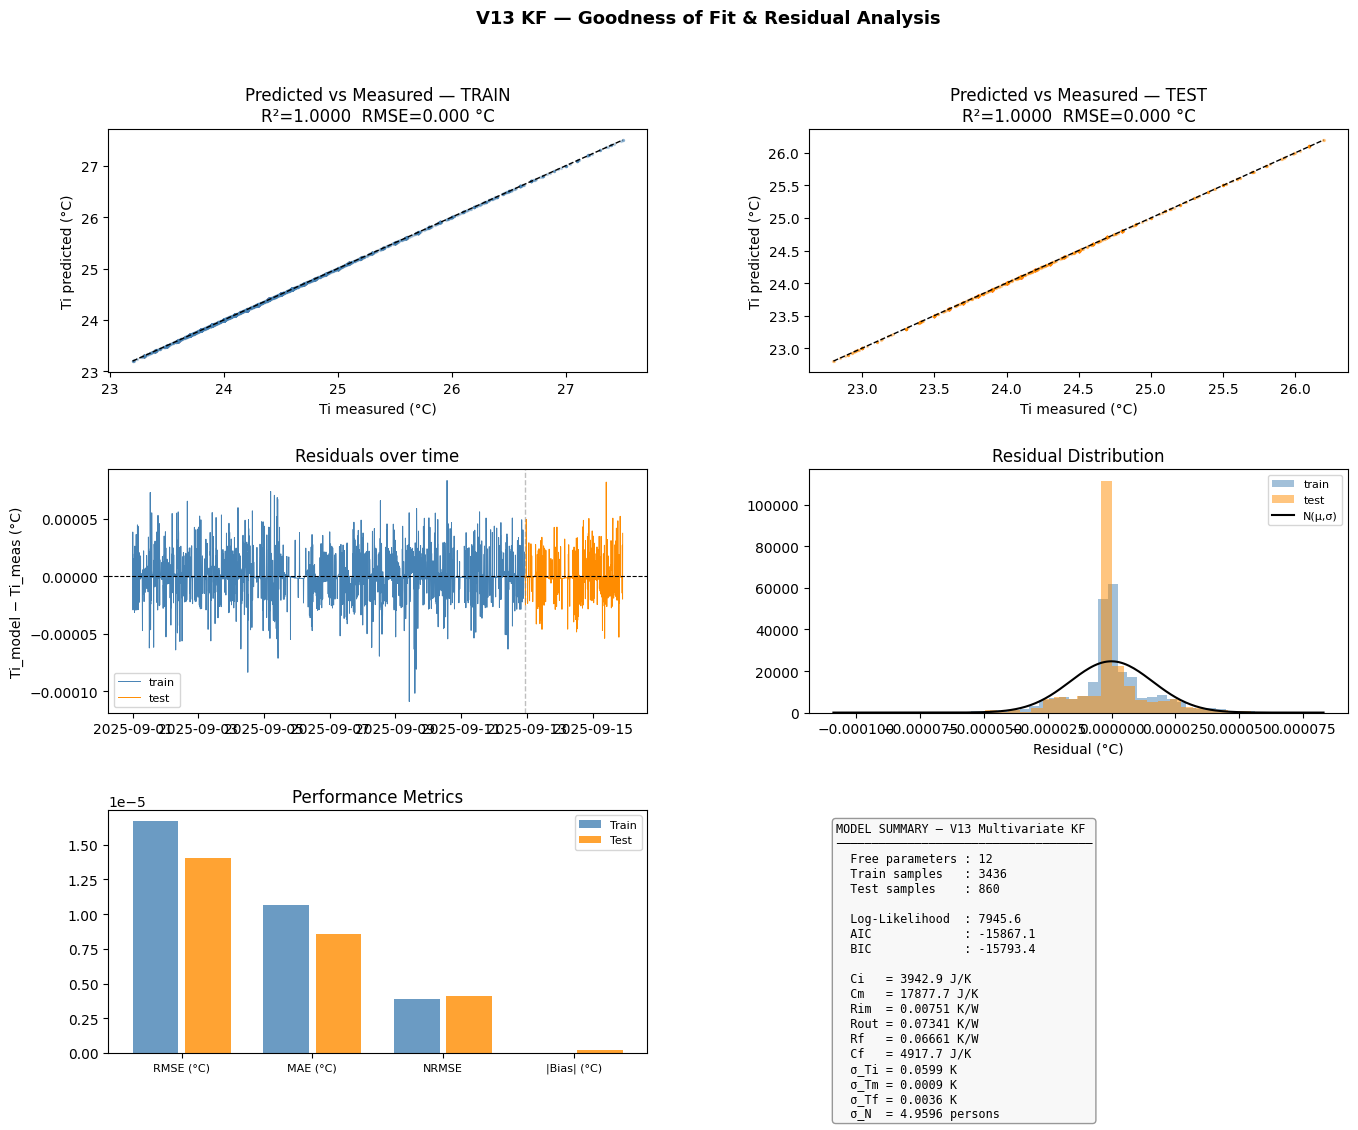

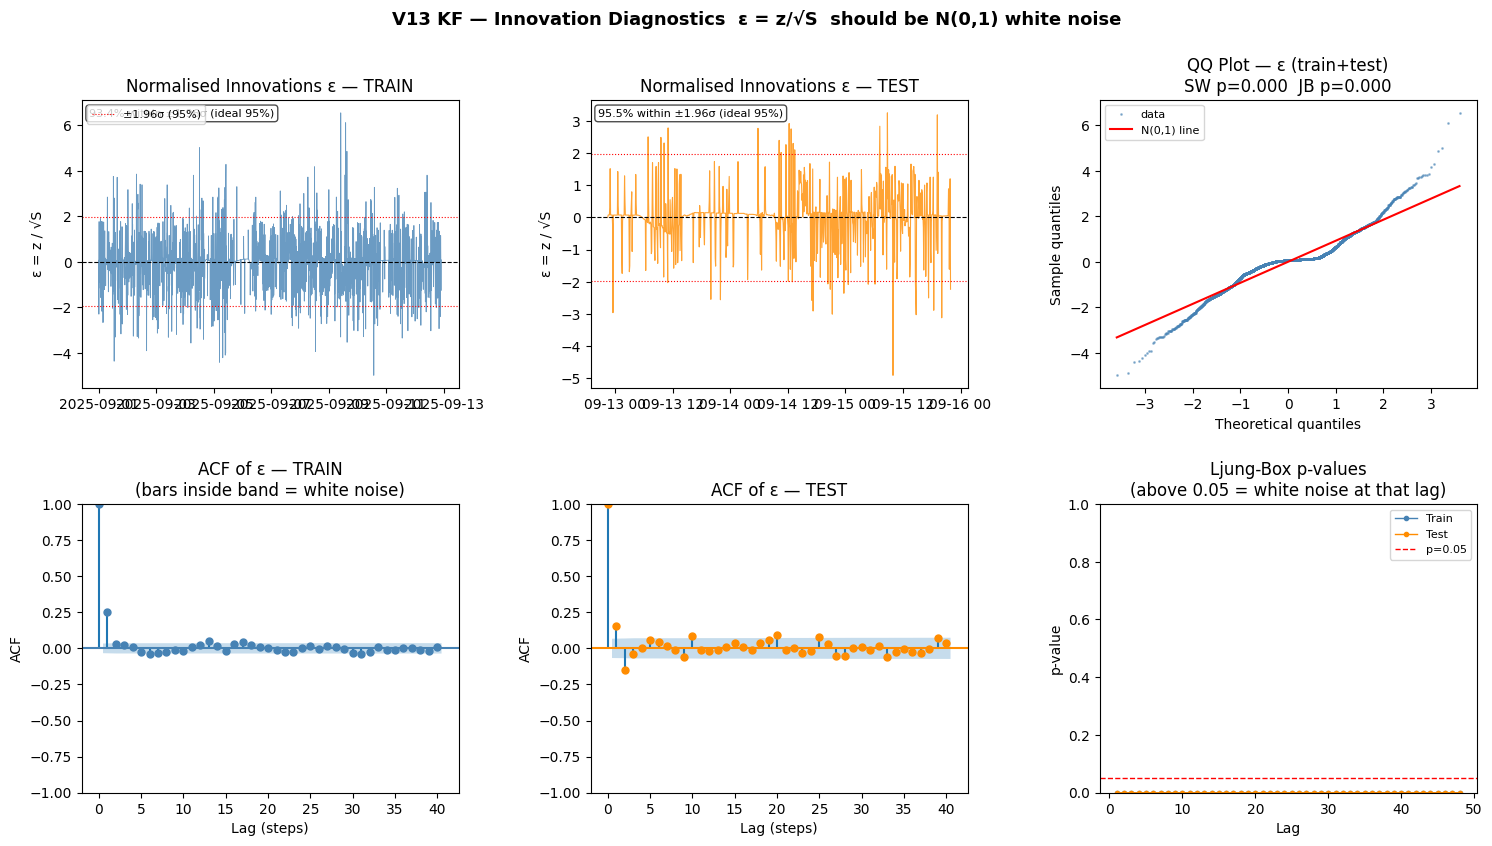

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats
from scipy.stats import jarque_bera, shapiro
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf

# ── Residuals ─────────────────────────────────────────────────────────────────
res_train = train_results.var['Ti'] - y_train.values
res_test  = test_results.var['Ti']  - y_test.values

# ── Normalised innovations ────────────────────────────────────────────────────
z_tr = train_results.var['z_Ti'][1:]
S_tr = train_results.var['S_Ti'][1:]
z_te = test_results.var['z_Ti'][1:]
S_te = test_results.var['S_Ti'][1:]
eps_train = z_tr / np.sqrt(np.abs(S_tr))
eps_test  = z_te / np.sqrt(np.abs(S_te))

# ── Metrics ───────────────────────────────────────────────────────────────────
n_params = sum(1 for p in fitted_params.values() if p.vary)
n_train  = len(y_train)
n_test   = len(y_test)

loglik_train = -0.5 * np.sum(z_tr**2 / S_tr + np.log(S_tr))
loglik_test  = -0.5 * np.sum(z_te**2 / S_te + np.log(S_te))
AIC = -2 * loglik_train + 2 * n_params
BIC = -2 * loglik_train + n_params * np.log(n_train)

def mae(pred, obs):   return np.mean(np.abs(pred - obs))
def nrmse(pred, obs): return rmse(pred, obs) / (obs.max() - obs.min())
def r2(pred, obs):    return 1 - np.sum((obs-pred)**2) / np.sum((obs-np.mean(obs))**2)
def bias(pred, obs):  return np.mean(pred - obs)

metrics = {
    'Train': dict(RMSE=rmse(train_results.var['Ti'], y_train.values),
                  MAE=mae(train_results.var['Ti'],   y_train.values),
                  NRMSE=nrmse(train_results.var['Ti'], y_train.values),
                  R2=r2(train_results.var['Ti'],     y_train.values),
                  Bias=bias(train_results.var['Ti'], y_train.values)),
    'Test':  dict(RMSE=rmse(test_results.var['Ti'],  y_test.values),
                  MAE=mae(test_results.var['Ti'],    y_test.values),
                  NRMSE=nrmse(test_results.var['Ti'], y_test.values),
                  R2=r2(test_results.var['Ti'],      y_test.values),
                  Bias=bias(test_results.var['Ti'],  y_test.values)),
}

sw_stat_tr, sw_p_tr = shapiro(eps_train[:5000])
jb_stat_tr, jb_p_tr = jarque_bera(eps_train)
sw_stat_te, sw_p_te = shapiro(eps_test)
jb_stat_te, jb_p_te = jarque_bera(eps_test)
lb_train = acorr_ljungbox(eps_train, lags=[1, 12, 24], return_df=True)
lb_test  = acorr_ljungbox(eps_test,  lags=[1, 12, 24], return_df=True)

# ── Print report ──────────────────────────────────────────────────────────────
sep = "═" * 55
print(f"\n{sep}")
print("  EXTENDED MODEL VALIDATION REPORT — V13 KF")   # ← V13
print(sep)
print(f"\n  {'GOODNESS OF FIT'}")
print(f"  {'Metric':<18} {'Train':>10} {'Test':>10}")
print(f"  {'-'*40}")
for k in ['RMSE', 'MAE', 'NRMSE', 'R2', 'Bias']:
    unit = ' °C' if k in ('RMSE','MAE','Bias') else ''
    print(f"  {k:<18} {metrics['Train'][k]:>10.4f}{unit}   {metrics['Test'][k]:>10.4f}{unit}")
print(f"\n  LIKELIHOOD-BASED CRITERIA (train)")
print(f"  Log-Likelihood : {loglik_train:.2f}")
print(f"  AIC            : {AIC:.2f}  (lower = better)")
print(f"  BIC            : {BIC:.2f}  (lower = better)")
print(f"  Free params    : {n_params}")
print(f"\n  KF INNOVATION DIAGNOSTICS")
print(f"  {'Test':<30} {'Train':>12} {'Test':>12}")
print(f"  {'-'*56}")
print(f"  {'ε mean (ideal=0)':<30} {eps_train.mean():>12.4f} {eps_test.mean():>12.4f}")
print(f"  {'ε std  (ideal=1)':<30} {eps_train.std():>12.4f} {eps_test.std():>12.4f}")
print(f"  {'Shapiro-Wilk  p-val':<30} {sw_p_tr:>12.4f} {sw_p_te:>12.4f}")
print(f"  {'Jarque-Bera   p-val':<30} {jb_p_tr:>12.4f} {jb_p_te:>12.4f}")
for lag, row_tr, row_te in zip([1,12,24],
    lb_train['lb_pvalue'].values, lb_test['lb_pvalue'].values):
    print(f"  {'Ljung-Box lag='+str(lag)+' p-val':<30} {row_tr:>12.4f} {row_te:>12.4f}")
print(f"\n  NOTE: p > 0.05 → cannot reject H0 (residuals white / Gaussian)")
print(sep + "\n")

# ── Figure 1: Goodness of fit ─────────────────────────────────────────────────
fig1, axes = plt.subplots(3, 2, figsize=(16, 12))
fig1.suptitle('V13 KF — Goodness of Fit & Residual Analysis',   # ← V13
              fontsize=13, fontweight='bold')
plt.subplots_adjust(hspace=0.4, wspace=0.3)

train_index = X_train.index
test_index  = X_test.index

ax = axes[0, 0]
mn, mx = y_train.min(), y_train.max()
ax.scatter(y_train, train_results.var['Ti'], s=2, alpha=0.3, color='steelblue')
ax.plot([mn, mx], [mn, mx], 'k--', lw=1)
ax.set_xlabel('Ti measured (°C)'); ax.set_ylabel('Ti predicted (°C)')
ax.set_title(f'Predicted vs Measured — TRAIN\nR²={metrics["Train"]["R2"]:.4f}  RMSE={metrics["Train"]["RMSE"]:.3f} °C')

ax = axes[0, 1]
mn, mx = y_test.min(), y_test.max()
ax.scatter(y_test, test_results.var['Ti'], s=2, alpha=0.3, color='darkorange')
ax.plot([mn, mx], [mn, mx], 'k--', lw=1)
ax.set_xlabel('Ti measured (°C)'); ax.set_ylabel('Ti predicted (°C)')
ax.set_title(f'Predicted vs Measured — TEST\nR²={metrics["Test"]["R2"]:.4f}  RMSE={metrics["Test"]["RMSE"]:.3f} °C')

ax = axes[1, 0]
ax.plot(train_index, res_train, color='steelblue',  lw=0.7, label='train')
ax.plot(test_index,  res_test,  color='darkorange', lw=0.7, label='test')
ax.axhline(0, color='black', lw=0.8, ls='--')
ax.axvline(test_index[0], color='grey', lw=1, ls='--', alpha=0.5)
ax.set_ylabel('Ti_model − Ti_meas (°C)'); ax.set_title('Residuals over time')
ax.legend(fontsize=8)

ax = axes[1, 1]
all_res = np.concatenate([res_train, res_test])
ax.hist(res_train, bins=50, density=True, alpha=0.5, color='steelblue',  label='train')
ax.hist(res_test,  bins=30, density=True, alpha=0.5, color='darkorange', label='test')
xr = np.linspace(all_res.min(), all_res.max(), 200)
ax.plot(xr, stats.norm.pdf(xr, all_res.mean(), all_res.std()), 'k-', lw=1.5, label='N(μ,σ)')
ax.set_xlabel('Residual (°C)'); ax.set_title('Residual Distribution')
ax.legend(fontsize=8)

ax = axes[2, 0]
bar_labels = ['RMSE (°C)', 'MAE (°C)', 'NRMSE', '|Bias| (°C)']
train_vals = [metrics['Train']['RMSE'], metrics['Train']['MAE'],
              metrics['Train']['NRMSE'], abs(metrics['Train']['Bias'])]
test_vals  = [metrics['Test']['RMSE'],  metrics['Test']['MAE'],
              metrics['Test']['NRMSE'],  abs(metrics['Test']['Bias'])]
x = np.arange(len(bar_labels))
ax.bar(x - 0.2, train_vals, 0.35, label='Train', color='steelblue',  alpha=0.8)
ax.bar(x + 0.2, test_vals,  0.35, label='Test',  color='darkorange', alpha=0.8)
ax.set_xticks(x); ax.set_xticklabels(bar_labels, fontsize=8)
ax.set_title('Performance Metrics'); ax.legend(fontsize=8)

ax = axes[2, 1]
ax.axis('off')
info = (
    f"MODEL SUMMARY — V13 Multivariate KF\n"           # ← V13
    f"{'─'*36}\n"
    f"  Free parameters : {n_params}\n"
    f"  Train samples   : {n_train}\n"
    f"  Test samples    : {n_test}\n\n"
    f"  Log-Likelihood  : {loglik_train:.1f}\n"
    f"  AIC             : {AIC:.1f}\n"
    f"  BIC             : {BIC:.1f}\n\n"
    f"  Ci   = {fitted_params['Ci'].value:.1f} J/K\n"
    f"  Cm   = {fitted_params['Cm'].value:.1f} J/K\n"
    f"  Rim  = {fitted_params['Rim'].value:.5f} K/W\n"
    f"  Rout = {fitted_params['Rout'].value:.5f} K/W\n"
    f"  Rf   = {fitted_params['Rf'].value:.5f} K/W\n"   # ← NEW
    f"  Cf   = {fitted_params['Cf'].value:.1f} J/K\n"   # ← NEW
    f"  σ_Ti = {fitted_params['sigma_Ti'].value:.4f} K\n"
    f"  σ_Tm = {fitted_params['sigma_Tm'].value:.4f} K\n"
    f"  σ_Tf = {fitted_params['sigma_Tf'].value:.4f} K\n"  # ← NEW
    f"  σ_N  = {fitted_params['sigma_N'].value:.4f} persons"
)
ax.text(0.05, 0.95, info, transform=ax.transAxes, va='top',
        fontsize=8.5, family='monospace',
        bbox=dict(boxstyle='round', fc='#f7f7f7', ec='grey', alpha=0.8))

plt.savefig('V13_goodness_of_fit.png', dpi=150, bbox_inches='tight')   # ← V13
plt.show()

# ── Figure 2: Innovation diagnostics ─────────────────────────────────────────
fig2, axes2 = plt.subplots(2, 3, figsize=(18, 9))
fig2.suptitle('V13 KF — Innovation Diagnostics  ε = z/√S  should be N(0,1) white noise',  # ← V13
              fontsize=13, fontweight='bold')
plt.subplots_adjust(hspace=0.4, wspace=0.35)

ax = axes2[0, 0]
ax.plot(train_index[1:], eps_train, lw=0.6, color='steelblue', alpha=0.8)
ax.axhline(0, color='black', lw=0.8, ls='--')
ax.axhline( 1.96, color='red', lw=0.8, ls=':', label='±1.96σ (95%)')
ax.axhline(-1.96, color='red', lw=0.8, ls=':')
ax.set_title('Normalised Innovations ε — TRAIN'); ax.set_ylabel('ε = z / √S')
ax.legend(fontsize=8)
pct_in = np.mean(np.abs(eps_train) < 1.96) * 100
ax.text(0.02, 0.97, f'{pct_in:.1f}% within ±1.96σ (ideal 95%)',
        transform=ax.transAxes, va='top', fontsize=8,
        bbox=dict(boxstyle='round', fc='white', alpha=0.7))

ax = axes2[0, 1]
ax.plot(test_index[1:], eps_test, lw=0.8, color='darkorange', alpha=0.8)
ax.axhline(0, color='black', lw=0.8, ls='--')
ax.axhline( 1.96, color='red', lw=0.8, ls=':')
ax.axhline(-1.96, color='red', lw=0.8, ls=':')
ax.set_title('Normalised Innovations ε — TEST'); ax.set_ylabel('ε = z / √S')
pct_in = np.mean(np.abs(eps_test) < 1.96) * 100
ax.text(0.02, 0.97, f'{pct_in:.1f}% within ±1.96σ (ideal 95%)',
        transform=ax.transAxes, va='top', fontsize=8,
        bbox=dict(boxstyle='round', fc='white', alpha=0.7))

ax = axes2[0, 2]
all_eps = np.concatenate([eps_train, eps_test])
(osm, osr), (slope, intercept, r) = stats.probplot(all_eps, dist='norm')
ax.plot(osm, osr, '.', ms=2, color='steelblue', alpha=0.5, label='data')
ax.plot(osm, slope*np.array(osm)+intercept, 'r-', lw=1.5, label='N(0,1) line')
ax.set_xlabel('Theoretical quantiles'); ax.set_ylabel('Sample quantiles')
ax.set_title(f'QQ Plot — ε (train+test)\nSW p={sw_p_tr:.3f}  JB p={jb_p_tr:.3f}')
ax.legend(fontsize=8)

ax = axes2[1, 0]
plot_acf(eps_train, lags=40, ax=ax, color='steelblue', alpha=0.05)
ax.set_title('ACF of ε — TRAIN\n(bars inside band = white noise)')
ax.set_xlabel('Lag (steps)'); ax.set_ylabel('ACF')

ax = axes2[1, 1]
plot_acf(eps_test, lags=40, ax=ax, color='darkorange', alpha=0.05)
ax.set_title('ACF of ε — TEST')
ax.set_xlabel('Lag (steps)'); ax.set_ylabel('ACF')

ax = axes2[1, 2]
max_lag = min(48, len(eps_train)//5)
lb_tr_full = acorr_ljungbox(eps_train, lags=range(1, max_lag+1), return_df=True)
lb_te_full = acorr_ljungbox(eps_test,  lags=range(1, max_lag+1), return_df=True)
ax.plot(lb_tr_full.index, lb_tr_full['lb_pvalue'], 'o-', ms=3,
        color='steelblue',  lw=1, label='Train')
ax.plot(lb_te_full.index, lb_te_full['lb_pvalue'], 'o-', ms=3,
        color='darkorange', lw=1, label='Test')
ax.axhline(0.05, color='red', lw=1, ls='--', label='p=0.05')
ax.set_xlabel('Lag'); ax.set_ylabel('p-value')
ax.set_title('Ljung-Box p-values\n(above 0.05 = white noise at that lag)')
ax.set_ylim(0, 1); ax.legend(fontsize=8)

plt.savefig('V13_innovation_diagnostics.png', dpi=150, bbox_inches='tight')  # ← V13
plt.show()


Fitted V13 params  ─────────────────────────────────────────┐
Historical N (from KF) → used as occupancy input            │
Modified qv schedule (night vent on/off) ──────────→  Open-loop Euler → Ti scenario
Historical Ta, Tsup, Ik, c ─────────────────────────────────┘


## Step 1 — Open-loop simulation function

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from itertools import product as iter_product

def simulate_night_vent_scenario(
    fitted_params,
    X_base,
    N_profile,          # occupancy from KF (np.array), shape (num_rec,)
    night_start_hour,   # e.g. 22  (inclusive)
    night_stop_hour,    # e.g. 7   (exclusive, crosses midnight allowed)
    qv_night,           # m3/h — night ventilation flow rate
    rec_duration,
    Ti_init, Tm_init, Tf_init, c_init
):
    """
    Open-loop V13 simulation with a modified night ventilation schedule.

    Night ventilation is only engaged when Ta < Ti (free cooling condition)
    AND the time is within [night_start_hour, night_stop_hour).
    Uses the historical KF-estimated N as occupancy input.
    """
    # ── Parameters ────────────────────────────────────────────────────────────
    Ci            = fitted_params['Ci'].value
    Cm            = fitted_params['Cm'].value
    Rim           = fitted_params['Rim'].value
    Rout          = fitted_params['Rout'].value
    Rf            = fitted_params['Rf'].value
    Cf            = fitted_params['Cf'].value
    q_equip_var   = fitted_params['q_equip_var'].value
    q_equip_const = fitted_params['q_equip_const'].value
    V             = fitted_params['V'].value
    S             = fitted_params['S'].value
    A             = fitted_params['A'].value
    c_out         = fitted_params['c_out'].value
    rho_air       = fitted_params['rho_air'].value
    cp_air        = fitted_params['cp_air'].value
    g             = fitted_params['g'].value
    Met           = fitted_params['Met'].value
    G_base        = fitted_params['G_base'].value
    alpha_lat     = fitted_params['alpha_lat'].value

    G      = G_base * Met
    q_sens = Met * (100.0 - alpha_lat)

    # ── Inputs → numpy ────────────────────────────────────────────────────────
    Ta    = np.asarray(X_base['Ta'],   dtype=float)
    Tsup  = np.asarray(X_base['Tsup'], dtype=float)
    qv    = np.asarray(X_base['qv'],   dtype=float)
    Ik    = np.asarray(X_base['Ik'],   dtype=float)
    num_rec = len(Ta)
    index   = X_base.index

    # ── Night ventilation mask ────────────────────────────────────────────────
    hours = np.array([t.hour + t.minute / 60.0 for t in index])
    if night_start_hour > night_stop_hour:       # crosses midnight
        night_mask = (hours >= night_start_hour) | (hours < night_stop_hour)
    else:
        night_mask = (hours >= night_start_hour) & (hours < night_stop_hour)

    # ── Precompute constants ──────────────────────────────────────────────────
    cp_rho_3600 = rho_air * cp_air / 3600.0
    gA          = g * A
    GV_1e6      = (G / V) * 1e6
    q_int_N     = q_sens + q_equip_var
    q_int_const = q_equip_const * S
    dt          = rec_duration

    # ── State transition matrix (constant, same as V13) ───────────────────────
    F = np.array([
        [1.0 - dt/(Rim*Ci) - dt/(Rout*Ci) - dt/(Rf*Ci),
               dt/(Rim*Ci),  dt/(Rf*Ci),  q_int_N*dt/Ci],
        [dt/(Rim*Cm),  1.0 - dt/(Rim*Cm),  0.0,  0.0],
        [dt/(Rf*Cf),   0.0,  1.0 - dt/(Rf*Cf),   0.0],
        [0.0, 0.0, 0.0, 1.0]
    ])

    # ── Allocate ──────────────────────────────────────────────────────────────
    Ti = np.zeros(num_rec);  Ti[0] = Ti_init
    Tm = np.zeros(num_rec);  Tm[0] = Tm_init
    Tf = np.zeros(num_rec);  Tf[0] = Tf_init
    c  = np.zeros(num_rec);  c[0]  = c_init

    # ── Open-loop Euler (no KF update) ───────────────────────────────────────
    for k in range(1, num_rec):
        N_k = float(N_profile[k-1])

        # Apply night ventilation only when outdoor is cooler than indoor
        if night_mask[k-1] and Ta[k-1] < Ti[k-1]:
            qv_k   = qv_night
            Tsup_k = Ta[k-1]          # free cooling: supply = outdoor air
        else:
            qv_k   = qv[k-1]
            Tsup_k = Tsup[k-1]

        Q_vent  = cp_rho_3600 * qv_k * (Tsup_k - Ti[k-1])
        Q_solar = gA * Ik[k-1]
        b0      = (Q_vent + Q_solar + q_int_const) * dt / Ci

        x     = np.array([Ti[k-1], Tm[k-1], Tf[k-1], N_k])
        x_new = F @ x
        x_new[0] += b0

        Ti[k] = x_new[0]
        Tm[k] = x_new[1]
        Tf[k] = x_new[2]

        dc   = (GV_1e6 * N_k - (qv_k / V) * (c[k-1] - c_out)) * dt
        c[k] = c[k-1] + dc

    return pd.DataFrame({'Ti': Ti, 'Tm': Tm, 'Tf': Tf, 'c': c}, index=index)


## Step 2 — Comfort metrics function

In [10]:
def comfort_metrics(Ti_series, index, occ_start=8, occ_end=18,
                    T_comfort_min=22.0, T_comfort_max=26.0):
    """
    Compute comfort metrics during occupied hours only.

    Returns dict with:
      - dh_above   : degree-hours above T_comfort_max
      - dh_below   : degree-hours below T_comfort_min
      - pct_ok     : % of occupied steps within comfort band
      - Ti_peak    : maximum Ti during occupied hours
      - Ti_mean    : mean Ti during occupied hours
    """
    hours       = np.array([t.hour + t.minute / 60.0 for t in index])
    occ_mask    = (hours >= occ_start) & (hours < occ_end)
    Ti_occ      = Ti_series[occ_mask]
    dt_h        = (index[1] - index[0]).seconds / 3600.0   # step in hours

    dh_above = float(np.sum(np.maximum(0, Ti_occ - T_comfort_max)) * dt_h)
    dh_below = float(np.sum(np.maximum(0, T_comfort_min - Ti_occ)) * dt_h)
    pct_ok   = float(np.mean((Ti_occ >= T_comfort_min) & (Ti_occ <= T_comfort_max)) * 100)
    Ti_peak  = float(Ti_occ.max())
    Ti_mean  = float(Ti_occ.mean())

    return dict(dh_above=dh_above, dh_below=dh_below,
                pct_ok=pct_ok, Ti_peak=Ti_peak, Ti_mean=Ti_mean)


## Step 3 — Baseline + single scenario comparison

Metric                        Baseline   Night vent 22-07
---------------------------------------------------------
dh_above                         11.23 °Ch           0.00 °Ch
dh_below                          0.00 °Ch           0.00 °Ch
pct_ok                           86.25 %         100.00 %
Ti_peak                          27.59 °C          25.98 °C
Ti_mean                          25.05 °C          24.06 °C


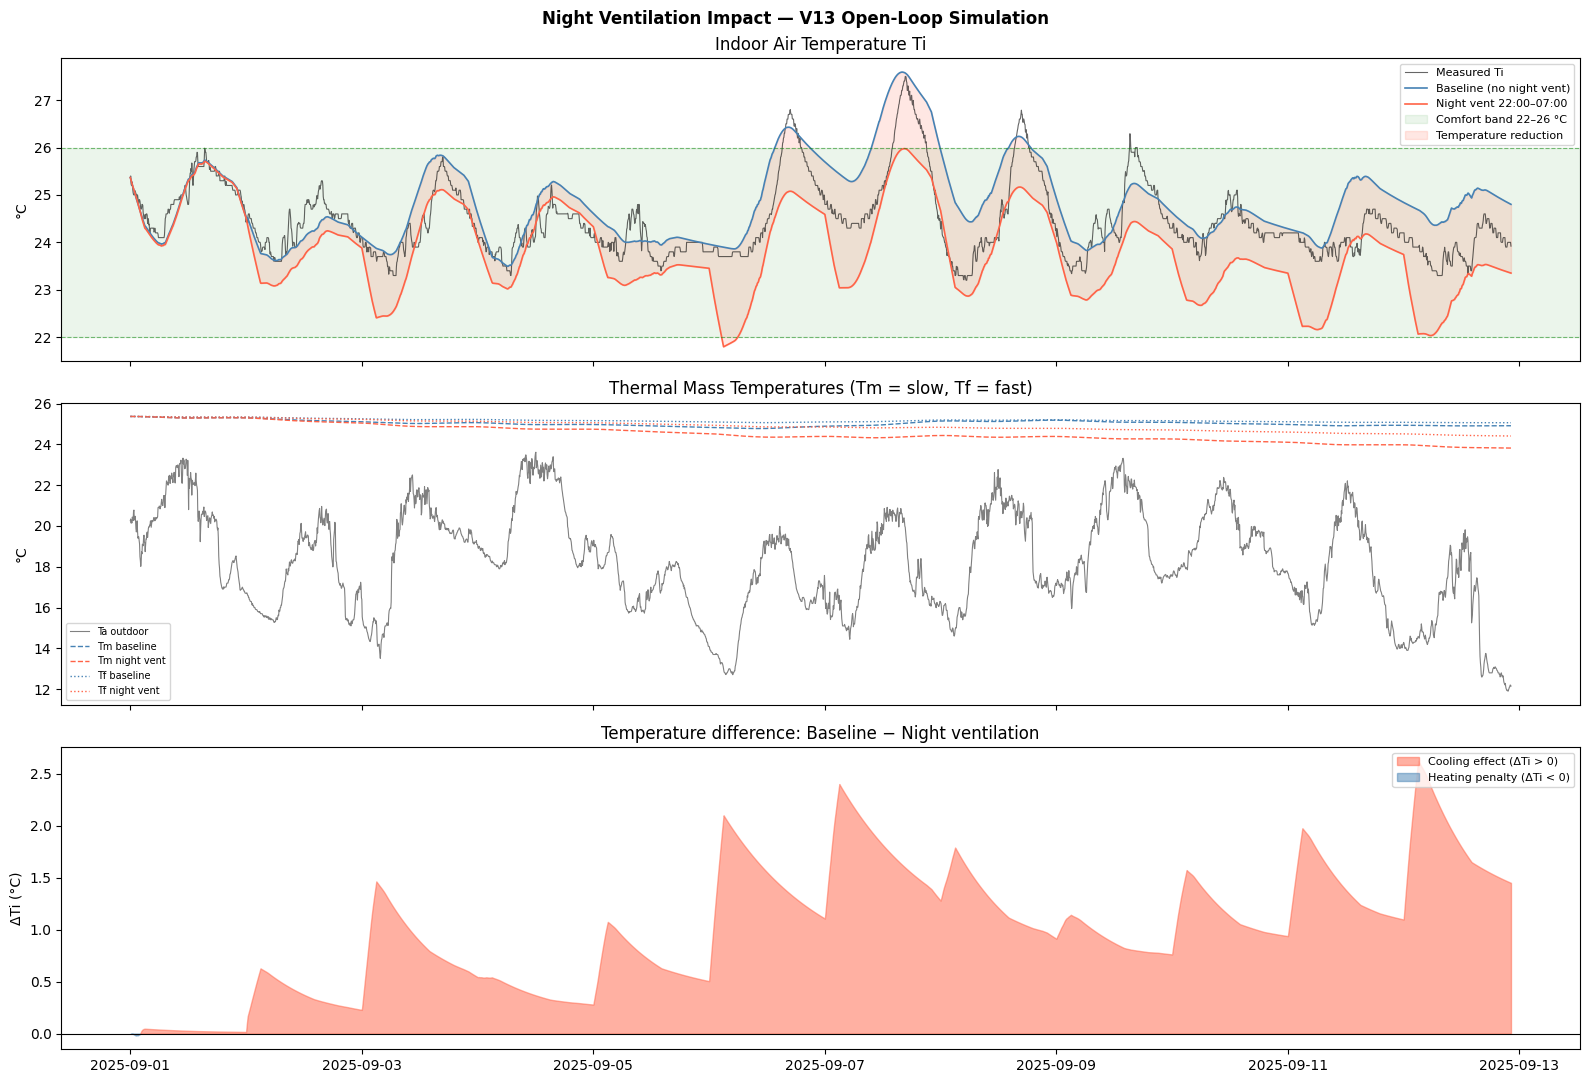

In [17]:
# ── Shared initial conditions and occupancy ──────────────────────────────────
Ti_init = float(y_train.iloc[0])
Tm_init = float(train_results.var['Tm'][0])
Tf_init = float(train_results.var['Tf'][0])
c_init  = float(train_results.var['c'][0])
N_hist  = train_results.var['N']      # KF-estimated occupancy from V13

# ── BASELINE: no extra night ventilation ─────────────────────────────────────
baseline = simulate_night_vent_scenario(
    fitted_params, X_train, N_hist,
    night_start_hour=0, night_stop_hour=0,   # no-op (mask always False)
    qv_night=0,
    rec_duration=rec_duration,
    Ti_init=Ti_init, Tm_init=Tm_init, Tf_init=Tf_init, c_init=c_init
)

# ── SCENARIO: night vent 22:00–07:00 at 3× normal flow ───────────────────────
qv_normal_max = float(np.percentile(np.asarray(X_train['qv'], dtype=float), 90))
qv_night_rate = 3.0 * qv_normal_max     # adjust to your system capacity

scenario = simulate_night_vent_scenario(
    fitted_params, X_train, N_hist,
    night_start_hour=0, night_stop_hour=3,
    qv_night=qv_night_rate,
    rec_duration=rec_duration,
    Ti_init=Ti_init, Tm_init=Tm_init, Tf_init=Tf_init, c_init=c_init
)

m_base = comfort_metrics(baseline['Ti'], X_train.index)
m_scen = comfort_metrics(scenario['Ti'], X_train.index)

print(f"{'Metric':<25} {'Baseline':>12} {'Night vent 22-07':>18}")
print("-" * 57)
for k in ['dh_above', 'dh_below', 'pct_ok', 'Ti_peak', 'Ti_mean']:
    unit = ' °Ch' if 'dh' in k else (' %' if 'pct' in k else ' °C')
    print(f"{k:<25} {m_base[k]:>12.2f}{unit}   {m_scen[k]:>12.2f}{unit}")

# ── Plot baseline vs scenario ─────────────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(16, 11), sharex=True)
fig.suptitle('Night Ventilation Impact — V13 Open-Loop Simulation', fontweight='bold')

ax = axes[0]
ax.plot(X_train.index, y_train,          color='black',     lw=0.8, alpha=0.6, label='Measured Ti')
ax.plot(X_train.index, baseline['Ti'],   color='steelblue', lw=1.2, label='Baseline (no night vent)')
ax.plot(X_train.index, scenario['Ti'],   color='tomato',    lw=1.2, label='Night vent 22:00–07:00')
ax.axhspan(22, 26, alpha=0.08, color='green', label='Comfort band 22–26 °C')
ax.axhline(26, color='green', lw=0.8, ls='--', alpha=0.5)
ax.axhline(22, color='green', lw=0.8, ls='--', alpha=0.5)
ax.fill_between(X_train.index,
    baseline['Ti'], scenario['Ti'],
    where=(baseline['Ti'] > scenario['Ti']),
    alpha=0.15, color='tomato', label='Temperature reduction')
ax.set_ylabel('°C');  ax.legend(fontsize=8);  ax.set_title('Indoor Air Temperature Ti')

ax = axes[1]
Ta_arr = np.asarray(X_train['Ta'], dtype=float)
ax.plot(X_train.index, Ta_arr,              color='grey',      lw=0.8, label='Ta outdoor')
ax.plot(X_train.index, baseline['Tm'],      color='steelblue', lw=1.0, ls='--', label='Tm baseline')
ax.plot(X_train.index, scenario['Tm'],      color='tomato',    lw=1.0, ls='--', label='Tm night vent')
ax.plot(X_train.index, baseline['Tf'],      color='steelblue', lw=1.0, ls=':',  label='Tf baseline')
ax.plot(X_train.index, scenario['Tf'],      color='tomato',    lw=1.0, ls=':',  label='Tf night vent')
ax.set_ylabel('°C');  ax.legend(fontsize=7);  ax.set_title('Thermal Mass Temperatures (Tm = slow, Tf = fast)')

ax = axes[2]
delta_Ti = baseline['Ti'].values - scenario['Ti'].values
ax.fill_between(X_train.index, delta_Ti, 0,
    where=(delta_Ti > 0), color='tomato',    alpha=0.5, label='Cooling effect (ΔTi > 0)')
ax.fill_between(X_train.index, delta_Ti, 0,
    where=(delta_Ti < 0), color='steelblue', alpha=0.5, label='Heating penalty (ΔTi < 0)')
ax.axhline(0, color='black', lw=0.8)
ax.set_ylabel('ΔTi (°C)');  ax.legend(fontsize=8)
ax.set_title('Temperature difference: Baseline − Night ventilation')

plt.tight_layout()
plt.savefig('night_vent_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


## Step 4 — Parameter sweep heatmap

Running sweep...
  Start 19h – Stop 04h → dh_above=0.0 °Ch  pct_ok=73.4%  Ti_peak=25.63°C
  Start 19h – Stop 05h → dh_above=0.0 °Ch  pct_ok=67.6%  Ti_peak=25.58°C
  Start 19h – Stop 06h → dh_above=0.0 °Ch  pct_ok=59.9%  Ti_peak=25.55°C
  Start 19h – Stop 07h → dh_above=0.0 °Ch  pct_ok=53.1%  Ti_peak=25.53°C
  Start 19h – Stop 08h → dh_above=0.0 °Ch  pct_ok=48.4%  Ti_peak=25.54°C
  Start 20h – Stop 04h → dh_above=0.0 °Ch  pct_ok=77.3%  Ti_peak=25.63°C
  Start 20h – Stop 05h → dh_above=0.0 °Ch  pct_ok=72.2%  Ti_peak=25.58°C
  Start 20h – Stop 06h → dh_above=0.0 °Ch  pct_ok=66.3%  Ti_peak=25.55°C
  Start 20h – Stop 07h → dh_above=0.0 °Ch  pct_ok=60.6%  Ti_peak=25.53°C
  Start 20h – Stop 08h → dh_above=0.0 °Ch  pct_ok=56.7%  Ti_peak=25.54°C
  Start 21h – Stop 04h → dh_above=0.0 °Ch  pct_ok=85.0%  Ti_peak=25.63°C
  Start 21h – Stop 05h → dh_above=0.0 °Ch  pct_ok=76.2%  Ti_peak=25.58°C
  Start 21h – Stop 06h → dh_above=0.0 °Ch  pct_ok=71.7%  Ti_peak=25.55°C
  Start 21h – Stop 07h → dh_above=

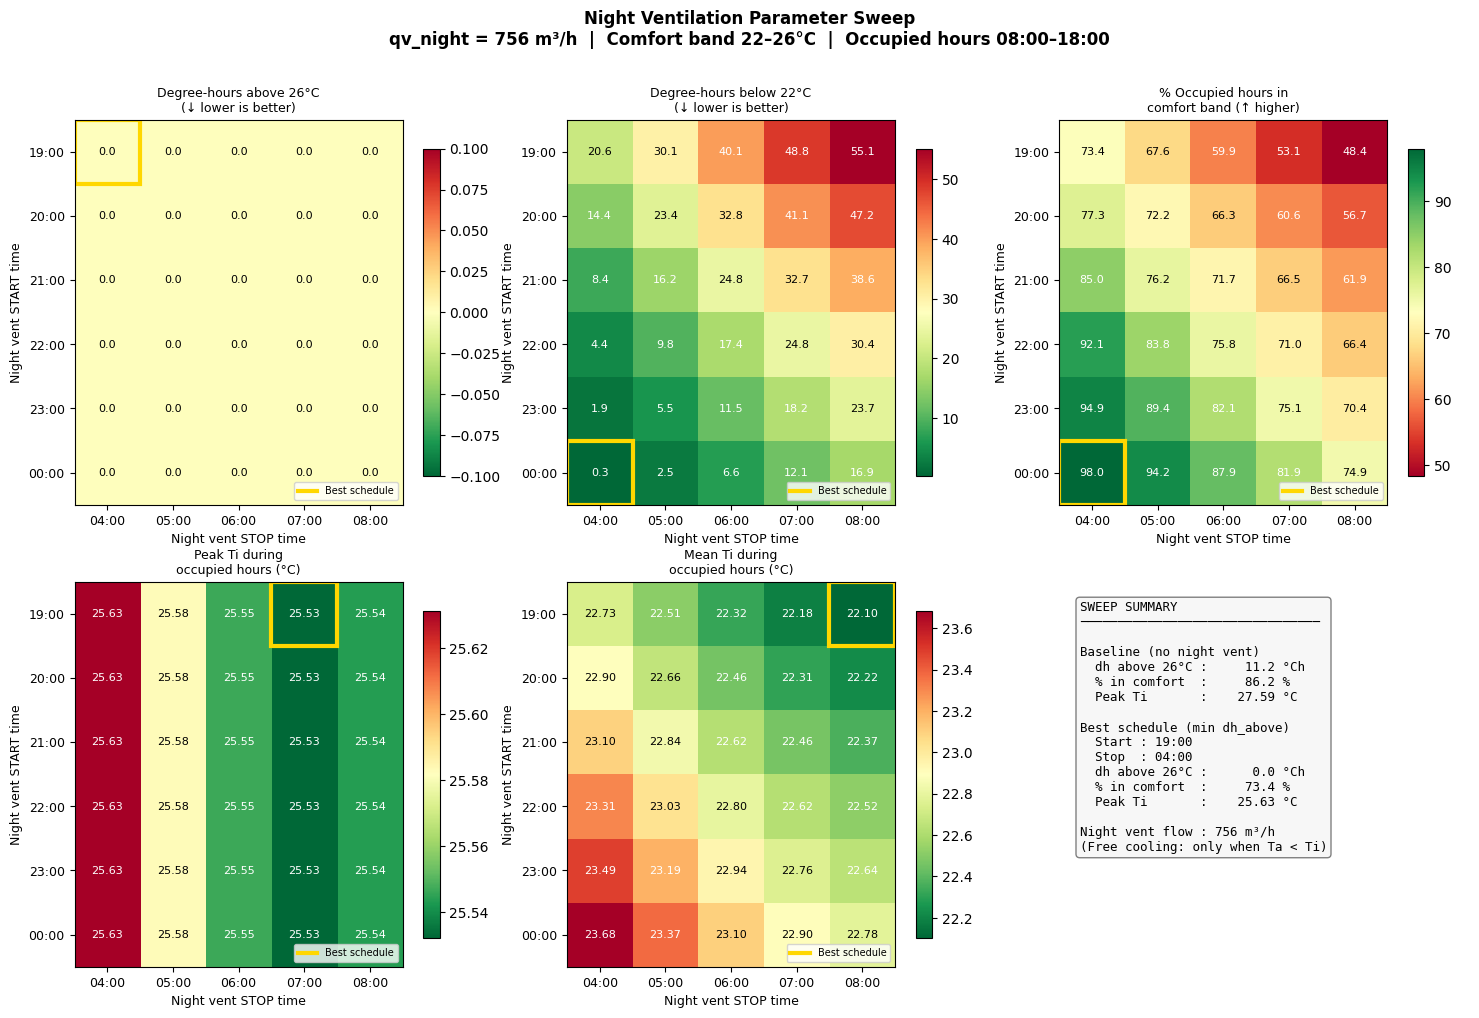

In [12]:
# ── Define sweep grid ─────────────────────────────────────────────────────────
start_hours = [19, 20, 21, 22, 23, 0]     # when night vent turns ON
stop_hours  = [4,  5,  6,  7,  8]         # when night vent turns OFF

results_grid = np.zeros((len(start_hours), len(stop_hours), 5))  # 5 metrics

print("Running sweep...")
for i, sh in enumerate(start_hours):
    for j, eh in enumerate(stop_hours):
        sim = simulate_night_vent_scenario(
            fitted_params, X_train, N_hist,
            night_start_hour=sh, night_stop_hour=eh,
            qv_night=qv_night_rate,
            rec_duration=rec_duration,
            Ti_init=Ti_init, Tm_init=Tm_init, Tf_init=Tf_init, c_init=c_init
        )
        m = comfort_metrics(sim['Ti'], X_train.index)
        results_grid[i, j, 0] = m['dh_above']
        results_grid[i, j, 1] = m['dh_below']
        results_grid[i, j, 2] = m['pct_ok']
        results_grid[i, j, 3] = m['Ti_peak']
        results_grid[i, j, 4] = m['Ti_mean']
        print(f"  Start {sh:02d}h – Stop {eh:02d}h → "
              f"dh_above={m['dh_above']:.1f} °Ch  "
              f"pct_ok={m['pct_ok']:.1f}%  "
              f"Ti_peak={m['Ti_peak']:.2f}°C")

print("Sweep complete.")

# ── Heatmaps ─────────────────────────────────────────────────────────────────
xlabels = [f"{h:02d}:00" for h in stop_hours]
ylabels = [f"{h:02d}:00" for h in start_hours]

metric_names  = ['Degree-hours above 26°C\n(↓ lower is better)',
                 'Degree-hours below 22°C\n(↓ lower is better)',
                 '% Occupied hours in\ncomfort band (↑ higher)',
                 'Peak Ti during\noccupied hours (°C)',
                 'Mean Ti during\noccupied hours (°C)']
metric_cmaps  = ['RdYlGn_r', 'RdYlGn_r', 'RdYlGn', 'RdYlGn_r', 'RdYlGn_r']
metric_fmt    = ['.1f', '.1f', '.1f', '.2f', '.2f']

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle(f'Night Ventilation Parameter Sweep\n'
             f'qv_night = {qv_night_rate:.0f} m³/h  |  '
             f'Comfort band 22–26°C  |  Occupied hours 08:00–18:00',
             fontsize=12, fontweight='bold')
axes = axes.flatten()

for idx in range(5):
    ax   = axes[idx]
    data = results_grid[:, :, idx]
    im   = ax.imshow(data, cmap=metric_cmaps[idx], aspect='auto')
    plt.colorbar(im, ax=ax, shrink=0.85)
    ax.set_xticks(range(len(stop_hours)));   ax.set_xticklabels(xlabels, fontsize=9)
    ax.set_yticks(range(len(start_hours))); ax.set_yticklabels(ylabels, fontsize=9)
    ax.set_xlabel('Night vent STOP time', fontsize=9)
    ax.set_ylabel('Night vent START time', fontsize=9)
    ax.set_title(metric_names[idx], fontsize=9)

    # Annotate cells
    for r in range(len(start_hours)):
        for c in range(len(stop_hours)):
            val = data[r, c]
            ax.text(c, r, f'{val:{metric_fmt[idx]}}',
                    ha='center', va='center', fontsize=8,
                    color='white' if im.norm(val) < 0.35 or im.norm(val) > 0.65
                    else 'black')

    # Mark best cell
    best = np.unravel_index(
        np.argmin(data) if idx != 2 else np.argmax(data), data.shape)
    ax.add_patch(plt.Rectangle(
        (best[1]-0.5, best[0]-0.5), 1, 1,
        fill=False, edgecolor='gold', lw=3, label='Best'))
    ax.legend(handles=[plt.Line2D([0],[0], color='gold', lw=3, label='Best schedule')],
              fontsize=7, loc='lower right')

# Baseline row (bottom right panel)
ax = axes[5]
ax.axis('off')
baseline_m = comfort_metrics(baseline['Ti'], X_train.index)
best_i, best_j = np.unravel_index(np.argmin(results_grid[:, :, 0]), results_grid[:, :, 0].shape)
best_m = {k: results_grid[best_i, best_j, v]
          for v, k in enumerate(['dh_above','dh_below','pct_ok','Ti_peak','Ti_mean'])}
summary = (
    f"SWEEP SUMMARY\n{'─'*32}\n\n"
    f"Baseline (no night vent)\n"
    f"  dh above 26°C : {baseline_m['dh_above']:>8.1f} °Ch\n"
    f"  % in comfort  : {baseline_m['pct_ok']:>8.1f} %\n"
    f"  Peak Ti       : {baseline_m['Ti_peak']:>8.2f} °C\n\n"
    f"Best schedule (min dh_above)\n"
    f"  Start : {start_hours[best_i]:02d}:00\n"
    f"  Stop  : {stop_hours[best_j]:02d}:00\n"
    f"  dh above 26°C : {best_m['dh_above']:>8.1f} °Ch\n"
    f"  % in comfort  : {best_m['pct_ok']:>8.1f} %\n"
    f"  Peak Ti       : {best_m['Ti_peak']:>8.2f} °C\n\n"
    f"Night vent flow : {qv_night_rate:.0f} m³/h\n"
    f"(Free cooling: only when Ta < Ti)"
)
ax.text(0.05, 0.95, summary, transform=ax.transAxes, va='top',
        fontsize=9, family='monospace',
        bbox=dict(boxstyle='round', fc='#f7f7f7', ec='grey'))

plt.savefig('night_vent_sweep.png', dpi=150, bbox_inches='tight')
plt.show()
